# 8. preprocessing — ML용 데이터 정리

**입력:** `apt_ml_master.csv` (덮어쓰기 금지)  
**근거:** `7_EDA_1_1.ipynb`  
**출력:** `apt_ml_ready.csv`

## 1. 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

INPUT  = 'apt_ml_master.csv'
OUTPUT = 'apt_ml_ready.csv'
AGING  = 'aging_rate_2019_2023.csv'
TARGET = 'dealAmount_num'
TARGET_LOG = 'log_dealAmount_num'  # ML 학습용 (원본은 MAE 보고용)

# 7_EDA_1_1 RF 후보 23개에서 noisy·raw 중복 제거한 최종 피처
FEATURES = [
    'excluUseAr_num', 'floor_num', 'buildYear', 'dealYear', 'dealMonth',
    'apt_age', 'nightlight_avg', 'nl_growth_trend', '고령화율',
    'sgg_count', 'SGG_level', 'sgg_yearly_volume', 'aging_intensity_per_nl',
    'cluster_name',
]

META_COLS = ['KOSIS_SGG_CODE', 'SGG_NM_norm']  # ML 평가·시각화용 (피처 아님)

print('설정 완료')

설정 완료


## 2. 로드

In [2]:
df = pd.read_csv(INPUT, encoding='utf-8-sig', low_memory=False)
print(f'로드: {len(df):,}행 , {df.shape[1]}컬럼')

로드: 2,396,830행 , 46컬럼


## 3. 결측 처리

In [3]:
aging = pd.read_csv(AGING, encoding='utf-8-sig')
aging['year'] = pd.to_numeric(aging['year'], errors='coerce')
aging['고령화율'] = pd.to_numeric(aging['고령화율'], errors='coerce')

gunwi = aging[aging['SGG_NM'].astype(str).str.contains('군위', na=False)].sort_values('year')
print('군위군 연도별 고령화율 (aging CSV)')
display(gunwi[['year', 'SGG_CODE', '고령화율']])

name_mask = df['SGG_NM'].astype(str).str.contains('군위', na=False)
old_code = df['sggCd'].astype(str).str.startswith('4772')
new_code = df['sggCd'].astype(str).str.startswith('2729')
gunwi_mask = name_mask | old_code | new_code
missing_mask = df['고령화율'].isna() & gunwi_mask

before = missing_mask.sum()
for idx in df[missing_mask].index:
    yr = df.loc[idx, 'dealYear']
    row = gunwi[gunwi['year'] == yr]
    df.loc[idx, '고령화율'] = row.iloc[0]['고령화율'] if len(row) else gunwi.iloc[-1]['고령화율']

df['SGG_NM_norm'] = df['SGG_NM']
df.loc[gunwi_mask, 'SGG_NM_norm'] = '대구광역시 군위군'

df['aptDong'] = df['aptDong'].fillna('')

print(f'고령화 fill: {before}건 → 남은 결측 {df["고령화율"].isna().sum()}건')

군위군 연도별 고령화율 (aging CSV)


,year,SGG_CODE,고령화율
1116,2019,37310,38.10
1117,2020,37310,39.65
1118,2021,37310,41.59
1119,2022,37310,42.81
245,2023,22520,44.05


고령화 fill: 93건 → 남은 결측 0건


## 4. 파생 변수 (FE)

In [4]:
# 시군구 거래량 5분위
sgg_count = df['SGG_NM'].value_counts()
df_sgg = sgg_count.reset_index()
df_sgg.columns = ['SGG_NM', 'sgg_count']
df_sgg['SGG_level'] = pd.qcut(
    df_sgg['sgg_count'], q=5,
    labels=['superlow', 'low', 'middle', 'high', 'superhigh'],
    duplicates='drop'
)
df = df.merge(df_sgg, on='SGG_NM', how='left')

# 파생 피처 생성
df['apt_age'] = df['dealYear'] - df['buildYear']
# buildYear > dealYear (425건) = 준공 전 분양권/입주권 거래 → 신축이므로 연식 0
df.loc[df['apt_age'] < 0, 'apt_age'] = 0

df['nl_growth_trend'] = df['nl_2023'] - df['nl_2019']

df['sgg_yearly_volume'] = df.groupby(['KOSIS_SGG_CODE', 'dealYear'])[TARGET].transform('count')

nl = df['nightlight_avg'].replace(0, np.nan)
df['aging_intensity_per_nl'] = df['고령화율'] / nl

print('FE 완료: sgg_count, SGG_level, apt_age, nl_growth_trend, sgg_yearly_volume, aging_intensity_per_nl')

FE 완료: sgg_count, SGG_level, apt_age, nl_growth_trend, sgg_yearly_volume, aging_intensity_per_nl


## 5. drop 근거표

RF 피처 후보 23개 중 저장하지 않는 컬럼과 이유.

In [5]:
drop_reason = [
    ('buyerGbn', '빈값이 많고 정보량 낮음'),
    ('cdealDay', '노이즈 많음'),
    ('cdealType', '노이즈 많음'),
    ('dealingGbn', '노이즈 많음'),
    ('landLeaseholdGbn', '노이즈 많음'),
    ('slerGbn', '노이즈 많음'),
    ('excluUseAr', 'excluUseAr_num으로 대체'),
    ('floor', 'floor_num으로 대체'),
    ('dealDay', 'RF 후보였으나 일별 패턴 근거 없어서 제외'),
    ('nl_2019', 'nl_growth_trend로 대체'),
    ('nl_2020', 'nl_growth_trend로 대체'),
    ('nl_2021', 'nl_growth_trend로 대체'),
    ('nl_2022', 'nl_growth_trend로 대체'),
    ('nl_2023', 'nl_growth_trend로 대체'),
]
drop_reason += [(c, '고카디널리티') for c in [
    'aptSeq','aptNm','jibun','roadNm','dealAmount','estateAgentSggNm',
    'aptDong','umdNm','rgstDate','SGG_NM'
]]
drop_reason += [(c, '식별자/주소코드') for c in [
    'sggCd','roadNmCd','LEGAL_SGG_CODE','landCd','roadNmSeq','umdCd',
    'roadNm','roadNmbCd','bonbun','bubun','roadNmBonbun','roadNmBubun','roadNmSggCd'
]]

drop_df = pd.DataFrame(drop_reason, columns=['column', 'reason'])
display(drop_df)
print(f'drop 대상 {len(drop_df)}개 (master 46컬럼 중)')

,column,reason
0,buyerGbn,§9 noisy — 빈값·정보량 낮음
1,cdealDay,§9 noisy
2,cdealType,§9 noisy
3,dealingGbn,§9 noisy
4,landLeaseholdGbn,§9 noisy
5,slerGbn,§9 noisy
6,excluUseAr,§12 raw — excluUseAr_num 사용
7,floor,§12 raw — floor_num 사용
8,dealDay,§12 RF 후보였으나 일별 패턴 근거 없음 → 제외
9,nl_2019,§24 연도별 nl — nl_growth_trend로 대체


drop 대상 37개 (master 46컬럼 중)


### 6. 타겟변수 로그화

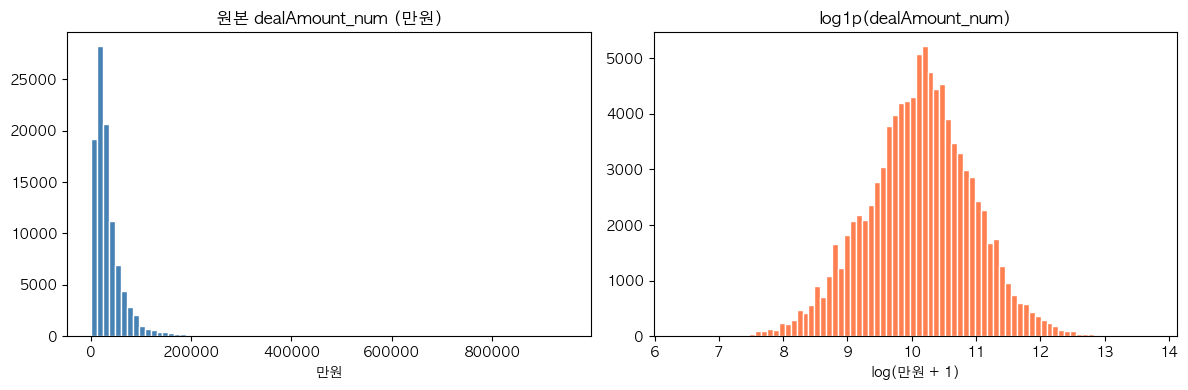

log_dealAmount_num 생성 완료
       dealAmount_num  log_dealAmount_num
count     2396830.000         2396830.000
mean        35067.553              10.126
std         35220.199               0.827
min           400.000               5.994
25%         14900.000               9.609
50%         25500.000              10.146
75%         43000.000              10.669
max       1800000.000              14.403

ML: log 타깃으로 학습 → 예측 후 np.expm1()으로 만원 복원 → MAE 계산


In [6]:
# 원본 vs log 분포 비교 (종 모양 확인)
sample = df[TARGET].dropna().sample(n=min(100_000, len(df)), random_state=42)
log_sample = np.log1p(sample)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sample, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('원본 dealAmount_num (만원)')
axes[0].set_xlabel('만원')

axes[1].hist(log_sample, bins=80, color='coral', edgecolor='white')
axes[1].set_title('log1p(dealAmount_num)')
axes[1].set_xlabel('log(만원 + 1)')

plt.tight_layout()
plt.show()

# log 타깃 생성 — log1p: 0 이하 방어 + 왜도 완화
df[TARGET_LOG] = np.log1p(df[TARGET])

print(f'{TARGET_LOG} 생성 완료')
print(df[[TARGET, TARGET_LOG]].describe().round(3))
print('\nML: log 타깃으로 학습 → 예측 후 np.expm1()으로 만원 복원 → MAE 계산')

## 6. 최종 컬럼 선택 · 검증


In [7]:
before = len(df)
df = df.dropna(subset=[TARGET])

out_cols = FEATURES + [TARGET, TARGET_LOG] + META_COLS
missing = [c for c in out_cols if c not in df.columns]
if missing:
    raise ValueError(f'컬럼 없음: {missing}')

df_out = df[out_cols].copy()

print(f'행: {before:,} → {len(df_out):,} (타깃 결측 {before - len(df_out)}건)')
print(f'컬럼: {len(out_cols)} = 피처 {len(FEATURES)} + 타깃 2 + 메타 {len(META_COLS)}')
print('\n피처 목록:')
for i, c in enumerate(FEATURES, 1):
    na = df_out[c].isna().sum()
    print(f'  {i:2d}. {c:<28} 결측 {na:,}')

na_cols = df_out.isna().sum()
if na_cols[na_cols > 0].any():
    print('\n⚠ 결측 있는 컬럼:')
    print(na_cols[na_cols > 0])

행: 2,396,830 → 2,396,830 (타깃 결측 0건)
컬럼: 18 = 피처 14 + 타깃 2 + 메타 2

피처 목록:
   1. excluUseAr_num               결측 0
   2. floor_num                    결측 0
   3. buildYear                    결측 0
   4. dealYear                     결측 0
   5. dealMonth                    결측 0
   6. apt_age                      결측 0
   7. nightlight_avg               결측 0
   8. nl_growth_trend              결측 0
   9. 고령화율                         결측 0
  10. sgg_count                    결측 0
  11. SGG_level                    결측 0
  12. sgg_yearly_volume            결측 0
  13. aging_intensity_per_nl       결측 0
  14. cluster_name                 결측 0


## 7. 저장

In [8]:
df_out.to_csv(OUTPUT, index=False, encoding='utf-8-sig')
print(f'저장: {OUTPUT}')
print(f'{len(df_out):,}행 × {df_out.shape[1]}컬럼')
print('\n컬럼:', df_out.columns.tolist())

저장: apt_ml_ready.csv
2,396,830행 × 18컬럼

컬럼: ['excluUseAr_num', 'floor_num', 'buildYear', 'dealYear', 'dealMonth', 'apt_age', 'nightlight_avg', 'nl_growth_trend', '고령화율', 'sgg_count', 'SGG_level', 'sgg_yearly_volume', 'aging_intensity_per_nl', 'cluster_name', 'dealAmount_num', 'log_dealAmount_num', 'KOSIS_SGG_CODE', 'SGG_NM_norm']


## 8. EDA에 없는 것 (ML 노트북에서 결정)

| 항목 | 상태 |
|------|------|
| `buildYear` vs `apt_age` | RF에 둘 다 포함 — VIF·중요도 보고 ML에서 하나만 써도 됨 |
| `cluster_name` 인코딩 | EDA는 one-hot — ML에서 Label/One-Hot 선택 |
| `SGG_level` 인코딩 | ordinal처럼 보이나 qcut 라벨 — ML에서 처리 |
| 저광도 subset CSV | EDA_1_1에 없음 — `cluster_name=='저광도'` 필터는 ML 단계 |
| `log_dealAmount_num` | ML 학습 타깃 — 예측 후 `expm1()`으로 만원 복원 후 MAE |
| 범주형 결측 median fill | EDA에서 참고만 함 — ML 파이프라인에서 직접 처리 |